In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings('ignore')


In [3]:
df=pd.read_csv("/Users/jayanto/Documents/code/customer_feedback/Restaurant_Reviews.tsv",sep="\t")

In [4]:
print(df.head())
df.shape

                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1


(1000, 2)

In [5]:
df.isnull().sum()

Review    0
Liked     0
dtype: int64

In [6]:
df["Liked"].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

In [7]:
df["char_count"]=df["Review"].apply(len)

In [8]:
df.head()

,Review,Liked,char_count
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


In [9]:
df["word_count"]=df["Review"].apply(lambda x :len (str(x).split()))

In [10]:
df.head()

,Review,Liked,char_count,word_count
0,Wow... Loved this place.,1,24,4
1,Crust is not good.,0,18,4
2,Not tasty and the texture was just nasty.,0,41,8
3,Stopped by during the late May bank holiday of...,1,87,15
4,The selection on the menu was great and so wer...,1,59,12


In [11]:
import nltk

In [12]:
nltk.download("punkt")


[nltk_data] Downloading package punkt to /Users/jayanto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [13]:
df["sent_count"]=df["Review"].apply(lambda x : len(nltk.sent_tokenize(str(x))))

In [14]:
df.head()

,Review,Liked,char_count,word_count,sent_count
0,Wow... Loved this place.,1,24,4,2
1,Crust is not good.,0,18,4,1
2,Not tasty and the texture was just nasty.,0,41,8,1
3,Stopped by during the late May bank holiday of...,1,87,15,1
4,The selection on the menu was great and so wer...,1,59,12,1


In [15]:
df[df["Liked"]==1]["char_count"].mean()


np.float64(55.88)

In [16]:
df[df["Liked"]==0]["char_count"].mean()


np.float64(60.75)

In [17]:
import re

In [18]:
df["Review"][0]

'Wow... Loved this place.'

In [19]:
review = re.sub("[^a-zA-Z]", " ", df["Review"][0])

In [20]:
review


'Wow    Loved this place '

In [21]:
review=review.lower()

In [22]:
review=review.split()
review

['wow', 'loved', 'this', 'place']

In [23]:
from nltk.corpus import stopwords
all_stopwords=stopwords.words("english")
all_stopwords.remove("not")

In [24]:
review= [word for word in review if word not in set (all_stopwords)]

In [25]:
from nltk.stem.porter import PorterStemmer

In [26]:
ps = PorterStemmer()

In [27]:
review=[ps.stem(word)for word in review]

In [28]:
review =" ".join(review)

In [29]:
review

'wow love place'

In [30]:
import re
custom_stopwords = {"no","not","nor","never","don","don't","doesn","doesn't",
                        "didn","didn't","isn","isn't","aren","aren't","wasn",
                      "wasn't","weren","weren't","won","won't","wouldn","wouldn't",
                      "couldn","couldn't","shouldn","shouldn't","shan","shan't",
                      "ain","ain't","haven","haven't","hasn","hasn't","hadn","hadn't",
                      "can","can't","cannot"}
corpus=[]
ps=PorterStemmer()
stop_words=set(stopwords.words("english"))-custom_stopwords
for i in range(len(df)):
    review = re.sub("[^a-zA-Z]", " ", df["Review"][i])
    review=review.lower()
    review=review.split()
    review=[ps.stem(word)for word in review if word not in stop_words]
    review=" ".join(review)
    corpus.append(review)

In [31]:
df["processed_text"]=corpus


In [32]:
df.head()

,Review,Liked,char_count,word_count,sent_count,processed_text
0,Wow... Loved this place.,1,24,4,2,wow love place
1,Crust is not good.,0,18,4,1,crust not good
2,Not tasty and the texture was just nasty.,0,41,8,1,not tasti textur nasti
3,Stopped by during the late May bank holiday of...,1,87,15,1,stop late may bank holiday rick steve recommen...
4,The selection on the menu was great and so wer...,1,59,12,1,select menu great price


In [33]:
from wordcloud import WordCloud

In [34]:
wc= WordCloud(width=500,height=500,min_font_size=8,background_color="black")

In [35]:
pos=wc.generate(df[df["Liked"]==1]["processed_text"].str.cat(sep=" "))

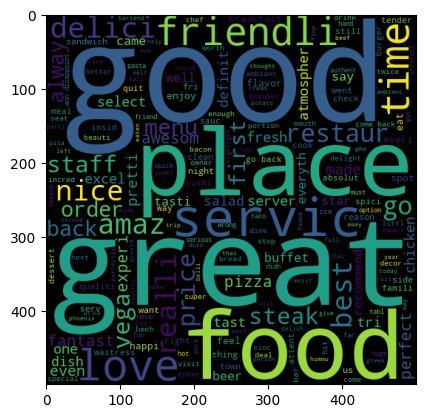

In [36]:
plt.imshow(pos)

In [37]:
ne=wc.generate(df[df["Liked"]==0]["processed_text"].str.cat(sep=" "))

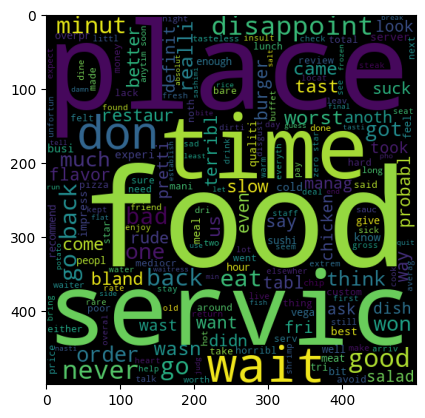

In [38]:
plt.imshow(ne)

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

In [40]:
cv=CountVectorizer(max_features=1500)

In [41]:
x=cv.fit_transform(corpus).toarray()

In [42]:
x.shape


(1000, 1500)

In [43]:
y =df["Liked"]
y

0      1
1      0
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Liked, Length: 1000, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [47]:
nb  =GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
accuracy_score(y_test,y_pred)

0.68

In [48]:
from sklearn.linear_model import LogisticRegression
lr  = LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
accuracy_score(y_test,y_pred)

0.785

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf  = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy_score(y_test,y_pred)

0.765

In [50]:
import joblib

In [51]:


joblib.dump(lr, "Restaurant_review_model")


print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [1]:
import tkinter as tk
from tkinter import ttk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import joblib
import re


class RestaurantReviewApp:

    def __init__(self, master):
        self.master = master

        master.title("Restaurant Review Classification App")
        master.geometry("500x400")

        # Load model and vectorizer
        self.model = joblib.load("Restaurant_review_model")
        self.vectorizer = joblib.load("count_v_res")

        # Create and set up widgets
        title_font = ("Helvetica", 16, "bold")

        self.label = ttk.Label(
            master,
            text="Enter your restaurant review:",
            font=title_font
        )
        self.label.pack(pady=10)

        # User input box
        self.text_entry = tk.Text(
            master,
            height=5,
            width=40
        )
        self.text_entry.pack(pady=10)

        # Button style
        self.style = ttk.Style()

        self.style.configure(
            "Custom.TButton",
            font=("Helvetica", 12),
            width=15
        )

        self.style.map(
            "Custom.TButton",
            foreground=[
                ("pressed", "black"),
                ("active", "black")
            ]
        )

        # Classify button
        self.classify_button = ttk.Button(
            master,
            text="Classify",
            command=self.classify_review,
            style="Custom.TButton"
        )
        self.classify_button.pack(pady=10)

        # Result label
        self.result_label = ttk.Label(
            master,
            text=""
        )
        self.result_label.pack(pady=10)


    def preprocess_text(self, text):

        custom_stopwords = {
            "no", "not", "nor", "never",
            "don", "don't", "doesn", "doesn't",
            "didn", "didn't", "isn", "isn't",
            "aren", "aren't", "wasn", "wasn't",
            "weren", "weren't", "won", "won't",
            "wouldn", "wouldn't", "couldn", "couldn't",
            "shouldn", "shouldn't", "shan", "shan't",
            "ain", "ain't", "haven", "haven't",
            "hasn", "hasn't", "hadn", "hadn't",
            "can", "can't", "cannot"
        }

        ps = PorterStemmer()

        stop_words = set(
            stopwords.words("english")
        ) - custom_stopwords

        review = re.sub(
            "[^a-zA-Z]",
            " ",
            text
        )

        review = review.lower()
        review = review.split()

        review = [
            ps.stem(word)
            for word in review
            if word not in stop_words
        ]

        review = " ".join(review)

        return review


    def classify_review(self):

        user_input = self.text_entry.get(
            "1.0",
            "end-1c"
        )

        if not user_input.strip():
            self.result_label.config(
                text="Please enter a review."
            )
            return

        processed_input = self.preprocess_text(
            user_input
        )

        # Check if only stopwords were entered
        if not processed_input.strip():
            self.result_label.config(
                text="Please enter a meaningful review."
            )
            return

        processed_input_vectorized = self.vectorizer.transform(
            [processed_input]
        )

        prediction = self.model.predict(
            processed_input_vectorized
        )[0]

        sentiment = (
            "Positive"
            if prediction == 1
            else "Negative"
        )

        self.result_label.config(
            text=f"Predicted Sentiment: {sentiment}"
        )


# =========================================
# RUN APPLICATION
# =========================================

if __name__ == "__main__":

    root = tk.Tk()

    app = RestaurantReviewApp(root)

    root.mainloop()